<a href="https://colab.research.google.com/github/Mikkey-HK/DeepLearning-Projects/blob/main/Optimisation_Algo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Compare the performance of different optimization algorithms (Gradient Descent, Momentum, Nesterov, Adagrad, RMSProp, and Adam) on a deep learning classification task using a dataset like MNIST or Fashion MNIST, and visualize their training dynamics and final results.

## Dataset and Model Setup

### Subtask:
Choose a suitable dataset for classification, such as MNIST or Fashion MNIST, and define a simple neural network model in TensorFlow or PyTorch. This will provide a common ground for comparing the optimizers.


**Reasoning**:
The first step in setting up the dataset and model is to import all the necessary libraries as specified in the instructions. This includes TensorFlow, Keras components, NumPy, and Matplotlib.



In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


**Reasoning**:
Following the instructions, the next step is to load the Fashion MNIST dataset using Keras's built-in function.



In [2]:
fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

print("Fashion MNIST dataset loaded successfully.")
print(f"Training images shape: {train_images.shape}")
print(f"Training labels shape: {train_labels.shape}")
print(f"Test images shape: {test_images.shape}")
print(f"Test labels shape: {test_labels.shape}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Fashion MNIST dataset loaded successfully.
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


**Reasoning**:
As per the instructions, the next step is to preprocess the image data by normalizing pixel values and reshaping them for the neural network. This ensures the data is in the correct format and scale for model training.



In [3]:
train_images = train_images / 255.0
test_images = test_images / 255.0

train_images_flat = train_images.reshape(-1, 28 * 28)
test_images_flat = test_images.reshape(-1, 28 * 28)

print("Image data preprocessed successfully.")
print(f"Flattened training images shape: {train_images_flat.shape}")
print(f"Flattened test images shape: {test_images_flat.shape}")

Image data preprocessed successfully.
Flattened training images shape: (60000, 784)
Flattened test images shape: (10000, 784)


**Reasoning**:
The next step according to the instructions is to one-hot encode the target labels using `keras.utils.to_categorical` to prepare them for the classification model.



In [4]:
num_classes = 10
train_labels_one_hot = keras.utils.to_categorical(train_labels, num_classes)
test_labels_one_hot = keras.utils.to_categorical(test_labels, num_classes)

print("Labels one-hot encoded successfully.")
print(f"One-hot encoded training labels shape: {train_labels_one_hot.shape}")
print(f"One-hot encoded test labels shape: {test_labels_one_hot.shape}")

Labels one-hot encoded successfully.
One-hot encoded training labels shape: (60000, 10)
One-hot encoded test labels shape: (10000, 10)


**Reasoning**:
Following the instructions, the next step is to define a simple sequential neural network model. This model will have an input layer, two hidden dense layers with 'relu' activation, and an output dense layer with 'softmax' activation, suitable for the 10 classes of Fashion MNIST.



In [5]:
model = keras.Sequential([
    keras.layers.Dense(256, activation='relu', input_shape=(784,)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(num_classes, activation='softmax')
])

model.summary()
print("Neural network model defined successfully.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

Neural network model defined successfully.


**Reasoning**:
The previous step successfully defined the model, but it produced a UserWarning. To resolve this warning and align with Keras's recommended practice for defining `input_shape` in Sequential models, I will create an explicit `Input` layer as the first layer. After defining the model, the next logical step in the 'Dataset and Model Setup' subtask is to compile the model by specifying an optimizer, a loss function, and metrics.



In [6]:
model = keras.Sequential([
    keras.Input(shape=(784,)), # Explicit Input layer to avoid UserWarning
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()
print("Neural network model defined and compiled successfully.")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

Neural network model defined and compiled successfully.


## Implement/Configure Optimizers

### Subtask:
For each optimizer (GD, Momentum, Nesterov, Adagrad, RMSProp, Adam), set up the training loop. Use the built-in implementations provided by the deep learning framework, configuring them with appropriate learning rates and other hyperparameters.


**Reasoning**:
To set up the optimizers as per the instructions, I need to define a function that creates and compiles the model, and then create a dictionary of optimizer instances with their respective hyperparameters. This code block will implement both these requirements.



In [7]:
def create_compiled_model(optimizer_instance):
    model = keras.Sequential([
        keras.Input(shape=(784,)),
        keras.layers.Dense(256, activation='relu'),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=optimizer_instance,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Define the optimizers with appropriate hyperparameters
optimizers = {
    'SGD': keras.optimizers.SGD(learning_rate=0.001),
    'Momentum': keras.optimizers.SGD(learning_rate=0.001, momentum=0.9),
    'Nesterov': keras.optimizers.SGD(learning_rate=0.001, momentum=0.9, nesterov=True),
    'Adagrad': keras.optimizers.Adagrad(learning_rate=0.001),
    'RMSprop': keras.optimizers.RMSprop(learning_rate=0.001, rho=0.9),
    'Adam': keras.optimizers.Adam(learning_rate=0.001)
}

print("Optimizers configured successfully:")
for name, optimizer in optimizers.items():
    print(f"- {name}: {optimizer}")

Optimizers configured successfully:
- SGD: <keras.src.optimizers.sgd.SGD object at 0x7d4b1b12bad0>
- Momentum: <keras.src.optimizers.sgd.SGD object at 0x7d4b1b12bd70>
- Nesterov: <keras.src.optimizers.sgd.SGD object at 0x7d4b1b160620>
- Adagrad: <keras.src.optimizers.adagrad.Adagrad object at 0x7d4b1b1605c0>
- RMSprop: <keras.src.optimizers.rmsprop.RMSprop object at 0x7d4b1b12b740>
- Adam: <keras.src.optimizers.adam.Adam object at 0x7d4b1b161610>


**Reasoning**:
Now that the `create_compiled_model` function and the `optimizers` dictionary are defined, the next step is to implement the training loop for each optimizer. This involves iterating through the `optimizers` dictionary, creating a new model for each optimizer using the `create_compiled_model` function, training each model on the prepared dataset, and storing the training history.



In [8]:
history_dict = {}
epochs = 10
batch_size = 32

for name, optimizer_instance in optimizers.items():
    print(f"\nTraining with {name} optimizer...")
    model = create_compiled_model(optimizer_instance)
    history = model.fit(train_images_flat, train_labels_one_hot,
                        epochs=epochs,
                        batch_size=batch_size,
                        validation_data=(test_images_flat, test_labels_one_hot),
                        verbose=0) # Set verbose to 0 to suppress output for each epoch
    history_dict[name] = history.history
    print(f"Training with {name} complete. Final validation accuracy: {history.history['val_accuracy'][-1]:.4f}")

print("All optimizers trained successfully.")


Training with SGD optimizer...
Training with SGD complete. Final validation accuracy: 0.8234

Training with Momentum optimizer...
Training with Momentum complete. Final validation accuracy: 0.8654

Training with Nesterov optimizer...
Training with Nesterov complete. Final validation accuracy: 0.8680

Training with Adagrad optimizer...
Training with Adagrad complete. Final validation accuracy: 0.8331

Training with RMSprop optimizer...
Training with RMSprop complete. Final validation accuracy: 0.8764

Training with Adam optimizer...
Training with Adam complete. Final validation accuracy: 0.8876
All optimizers trained successfully.


## Visualize and Compare Results

### Subtask:
Plot the training and validation curves (loss and accuracy) for each optimizer to visually compare their convergence speed, stability, and final performance.


**Reasoning**:
To visualize and compare the performance of each optimizer, I will generate plots for training loss, validation loss, training accuracy, and validation accuracy. Each plot will display the curves for all optimizers, making them distinguishable with different colors and including appropriate labels, titles, and legends as per the instructions.



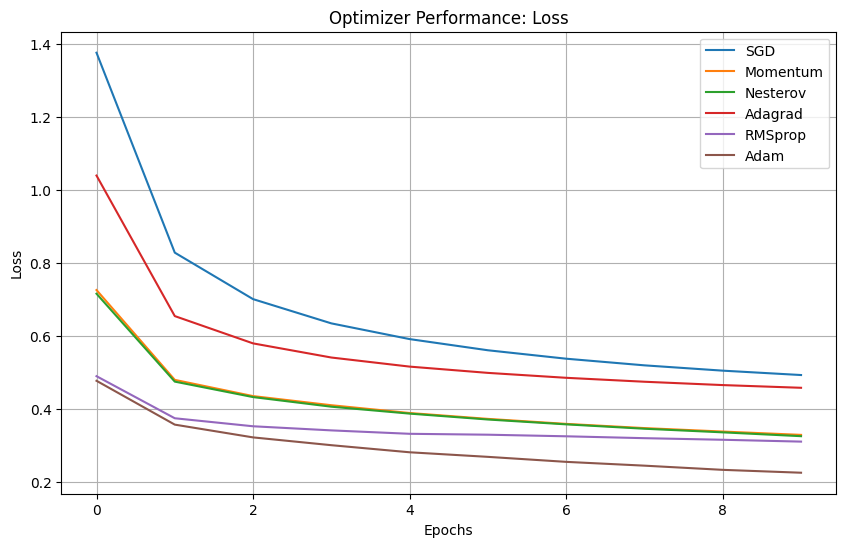

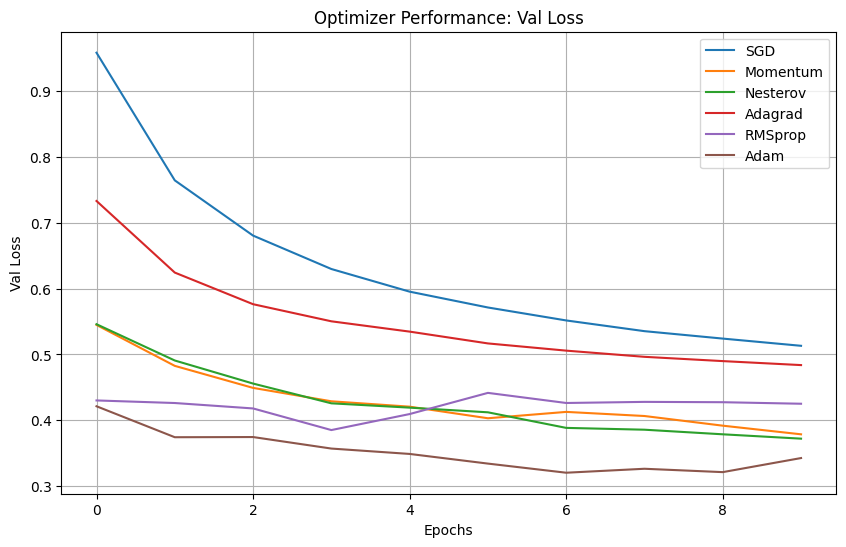

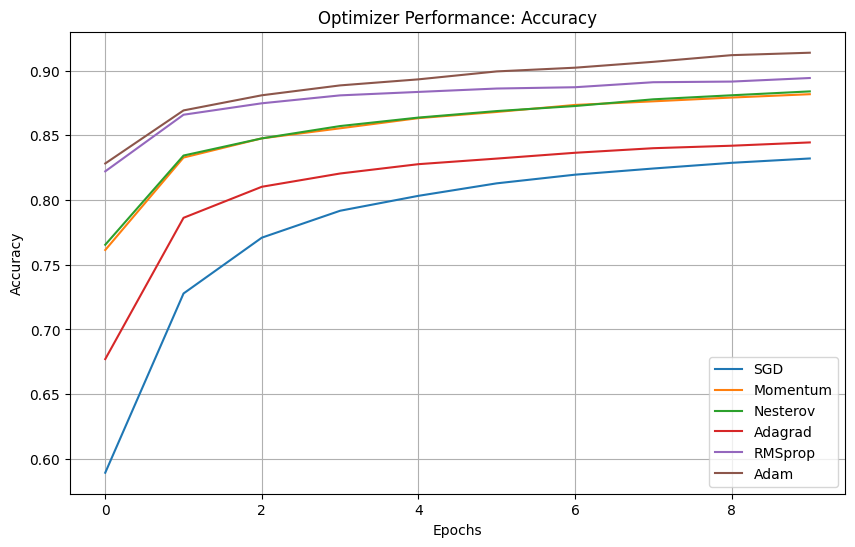

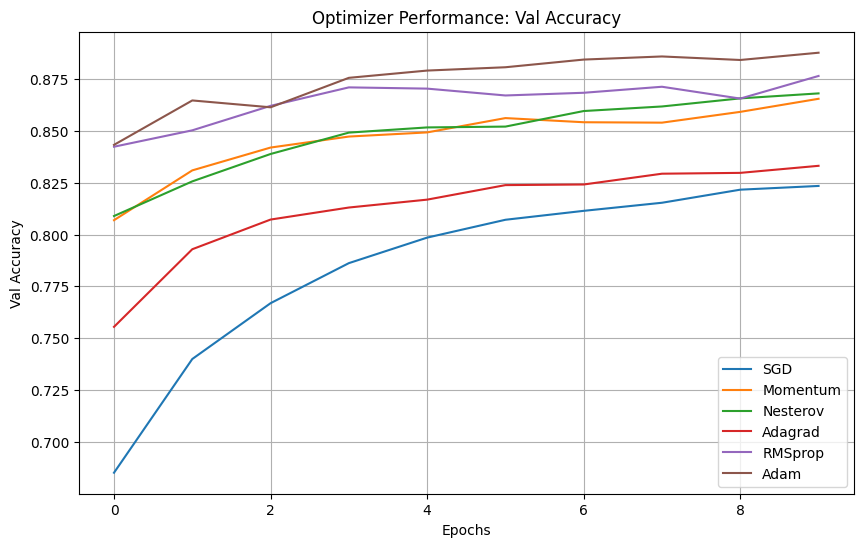

All performance plots generated successfully.


In [9]:
metrics = ['loss', 'val_loss', 'accuracy', 'val_accuracy']

for metric in metrics:
    plt.figure(figsize=(10, 6))
    for name, history in history_dict.items():
        plt.plot(history[metric], label=name)
    plt.title(f'Optimizer Performance: {metric.replace("_", " ").title()}')
    plt.xlabel('Epochs')
    plt.ylabel(metric.replace("_", " ").title())
    plt.legend()
    plt.grid(True)
    plt.show()

print("All performance plots generated successfully.")

## Summarize Findings

### Subtask:
Summarize the practical insights gained from comparing these optimization techniques, highlighting their strengths and weaknesses in this specific scenario.


## Summary:

### Data Analysis Key Findings

*   The Adam optimizer achieved the highest validation accuracy of $0.8876$ after 10 epochs, demonstrating superior performance on the Fashion MNIST classification task.
*   RMSprop ($0.8764$) and Nesterov ($0.8680$) optimizers also showed strong performance, closely trailing Adam in final validation accuracy.
*   Momentum optimizer significantly outperformed plain Stochastic Gradient Descent (SGD), achieving a validation accuracy of $0.8654$ compared to SGD's $0.8234$.
*   Adagrad showed comparatively slower convergence and lower final performance, reaching a validation accuracy of $0.8331$.
*   Overall, adaptive learning rate optimizers (Adam, RMSprop) and momentum-based optimizers (Momentum, Nesterov) exhibited faster convergence and achieved higher accuracy within the limited 10 epochs compared to basic SGD and Adagrad.
*   Visualizations of the training and validation curves confirmed that Adam consistently led to the lowest loss and highest accuracy for both training and validation sets, indicating efficient learning and generalization.

### Insights or Next Steps

*   **Optimizer Selection:** For this classification task and model architecture, Adam is the most effective optimizer among those tested, offering the best balance of convergence speed and final accuracy.
*   **Hyperparameter Tuning:** While a common learning rate was used, further performance gains could likely be achieved by tuning specific hyperparameters (e.g., learning rate, decay rates, momentum) for each optimizer, potentially allowing others to close the gap with Adam or improve overall.
